In [1]:
import math, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import numpy as np

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Define hyperparameters
IMG_SIZE = 32
EMBED_DIM = 64
ATTENTION_HEADS = 4
BATCH_SIZE = 12
EPOCHS = 50
LR = 0.001
TEMPERATURE = 0.07

### Dataset Creation & Preparation

In [4]:
# Define the possible colors, shapes, and positions for the synthetic dataset
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'pink', 'brown', 'gray']
shapes = ['square', 'circle', 'triangle']
positions = ['left', 'center', 'top', 'right', 'bottom', 'top-left', 'top-right', 'bottom-left', 'bottom-right']

In [5]:
# Function to draw an image with a specific color, shape, and position
def draw_img(color, shape, positions, img_size = IMG_SIZE):
    img = Image.new('RGB', (img_size, img_size), 'white')
    draw = ImageDraw.Draw(img)
    margin = 6
    w = h = img_size - 2 * margin

    if 'left' in positions:
        x0 = margin
        x1 = margin + w // 2
    elif 'top-left' in positions:
        x0 = margin
        x1 = margin + w // 2
    elif 'bottom-left' in positions:
        x0 = margin
        x1 = margin + w // 2
    elif 'right' in positions:
        x0 = margin + w // 2
        x1 = img_size - margin
    elif 'top-right' in positions:
        x0 = margin + w // 2
        x1 = img_size - margin
    elif 'bottom-right' in positions:
        x0 = margin + w // 2
        x1 = img_size - margin
    else:
        x0 = margin + w // 4
        x1 = margin + 3 * w // 4

    if 'top' in positions:
        y0 = margin
        y1 = margin + h // 2
    elif 'top-left' in positions:
        y0 = margin
        y1 = margin + h // 2
    elif 'top-right' in positions:
        y0 = margin
        y1 = margin + h // 2
    elif 'bottom' in positions:
        y0 = margin + h // 2
        y1 = img_size - margin
    elif 'bottom-left' in positions:
        y0 = margin + h // 2
        y1 = img_size - margin
    elif 'bottom-right' in positions:
        y0 = margin + h // 2
        y1 = img_size - margin
    else:
        y0 = margin + h // 4
        y1 = margin + 3 * h // 4

    if shape == 'square':
        draw.rectangle([x0, y0, x1, y1], fill=color, outline='black')
    elif shape == 'circle':
        draw.ellipse([x0, y0, x1, y1], fill=color, outline='black')
    elif shape == 'triangle':
        draw.polygon([(x0 + (x1 - x0) // 2, y0), (x0, y1), (x1, y1)], fill=color, outline='black')

    return img

In [6]:
# Define the ShapeDataset class to generate synthetic images and captions
class ShapeDataset():
    def __init__(self):
        self.images = []
        self.captions = []

        for c in colors:
            for s in shapes:
                for p in positions:
                    img = draw_img(c, s, p)
                    caption = f"{c} {s} {p}"

                    self.images.append(torch.from_numpy(np.asarray(img)).permute(2, 0, 1).float() / 255.0)
                    self.captions.append(caption)


        self.vocab, self.word2idx = self.build_vocab(self.captions)


    def build_vocab(self, texts):
        words = sorted({w for t in texts for w in t.split()})
        vocab = ['[CLS]'] + words
        w2i = {w:i for i, w in enumerate(vocab)}
        return vocab, w2i


    def encode_text(self, text):
        tokens = [self.word2idx['[CLS]']] + [self.word2idx[w] for w in text.split()]
        return torch.tensor(tokens, dtype = torch.long)


    def __getitem__(self, idx):
        return self.images[idx], self.encode_text(self.captions[idx])


    def __len__(self):
        return len(self.images)

In [7]:
# Create the dataset and print its vocabulary and length
dataset = ShapeDataset()
vocab = dataset.vocab
VOCAB_SIZE = len(vocab)
print(VOCAB_SIZE)
print(vocab)
len(dataset)

22
['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'gray', 'green', 'left', 'orange', 'pink', 'purple', 'red', 'right', 'square', 'top', 'top-left', 'top-right', 'triangle', 'yellow']


/tmp/ipykernel_27563/4019393924.py:13: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  self.images.append(torch.from_numpy(np.asarray(img)).permute(2, 0, 1).float() / 255.0)


243

In [8]:
# Split the dataset into training and testing sets
train_size = (int) (0.8 * len(dataset))
test_size = len(dataset) - train_size

train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])
print(len(train_set))
print(len(test_set))

194
49


In [9]:
# Create DataLoaders for the training and testing sets
train_loader = DataLoader(dataset=train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=BATCH_SIZE, shuffle=False)

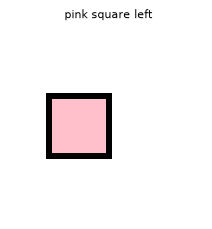

In [10]:
# Visualize a random image and its corresponding caption from the training set
imgs, encoded_caps = next(iter(train_loader))
idx = random.randint(0, len(imgs) - 1)
img = (imgs[idx].permute(1, 2, 0).numpy() * 255).astype(np.uint8)

caption_tokens = encoded_caps[idx].tolist()
caption = " ".join(dataset.vocab[token] for token in caption_tokens if token in range(len(dataset.vocab)))
caption = caption.replace('[CLS]', '')

plt.figure(figsize=(2.5, 2.5))
plt.imshow(img)
plt.title(caption, fontsize=8)
plt.axis('off')
plt.show()

### Model Architecture 

In [11]:
# Image Encoder: A simple CNN to extract features from the input images
class ImageEncoder(nn.Module):
    def __init__(self, embed_dim = EMBED_DIM):
        super().__init__()

        self.convolutions = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.ReLU()
        )

        self.projection = nn.Linear(256, embed_dim)
        self.layer_norm = nn.LayerNorm(embed_dim)


    def forward(self, X):
        out = self.convolutions(X)
        out = out.mean(dim=[2,3])          # avg pooling
        out = self.projection(out)
        out = F.normalize(self.layer_norm(out), dim=-1)

        return out

In [12]:
# Text Encoder
class TextEncoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, num_heads=ATTENTION_HEADS, context_window=4):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(context_window, embed_dim)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.projection_layer = nn.Linear(embed_dim, embed_dim)
        self.layer_norm = nn.LayerNorm(embed_dim)


    def forward(self, tokens):
        N, L = tokens.shape
        pos_emb_ids = torch.arange(L, device=tokens.device).unsqueeze(0).expand(N, L)
        pos_emb_vectors = self.position_embedding(pos_emb_ids)
        token_emb_vectors = self.token_embedding(tokens)
        final_embedding = token_emb_vectors + pos_emb_vectors
        context_vector = self.mha(final_embedding, final_embedding, final_embedding)[0]
        final_tokens = context_vector[:, 0]
        projection = self.projection_layer(final_tokens)
        output = F.normalize(self.layer_norm(projection), dim=-1)

        return output

In [13]:
# CLIP Loss
def clip_loss(img_embeddings, txt_embeddings, temperature = TEMPERATURE):
    logits = img_embeddings @ txt_embeddings.T / temperature
    targets = torch.arange(img_embeddings.size(0), device=img_embeddings.device)
    loss_i = F.cross_entropy(logits, targets)
    loss_t = F.cross_entropy(logits.T, targets)

    return (loss_i + loss_t) / 2.0

### Training

In [14]:
image_encoder = ImageEncoder().to(device)
text_encoder = TextEncoder().to(device)
params = list(image_encoder.parameters()) + list(text_encoder.parameters())
optimizer = torch.optim.AdamW(params, lr=LR)

In [15]:
# Function to plot image and text embedding vector's heatmap side by side
def plot_embeddings(
    img_emb: np.ndarray,
    txt_emb: np.ndarray,
    title_prefix: str = ""
):
    """Side-by-side heatmap bars of an image and text embedding vector."""
    fig, axes = plt.subplots(2, 1, figsize=(7, 1.8))
    for ax, emb, label in zip(axes, [img_emb, txt_emb], ["Image Emb", "Text Emb"]):
        ax.imshow(emb.reshape(1, -1), aspect="auto", cmap="viridis")
        ax.set_ylabel(label, fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(f"{title_prefix} Embedding Vectors", fontweight="bold", fontsize=10)
    fig.tight_layout()
    plt.show()


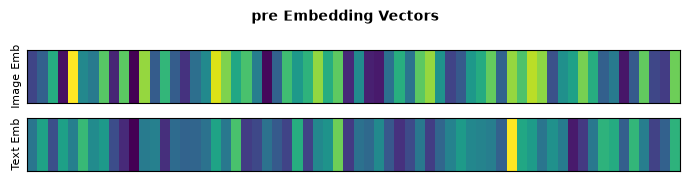

In [16]:
# Vizualize the embeddings before training
image_encoder.eval()
text_encoder.eval()

sample_img, sample_caption = dataset[0]
with torch.no_grad():
    img_emb = image_encoder(sample_img.unsqueeze(0).to(device))
    txt_emb = text_encoder(sample_caption.unsqueeze(0).to(device))

plot_embeddings(img_emb[0].cpu().numpy(), txt_emb[0].cpu().numpy(), "pre")


In [17]:
train_losses = []
val_losses = []
best_val = float('inf')

for epoch in range(1, EPOCHS + 1):
    # ── train ──────────────────────────────────────
    image_encoder.train()
    text_encoder.train()
    running, n = 0.0, 0

    for imgs, toks in train_loader:
        imgs, toks = imgs.to(device), toks.to(device)
        optimizer.zero_grad(set_to_none=True)

        loss = clip_loss(image_encoder(imgs), text_encoder(toks))
        loss.backward()
        optimizer.step()

        running += loss.item() * imgs.size(0)
        n += imgs.size(0)

    train_loss = running / n

    # ── validate ───────────────────────────────────
    image_encoder.eval()
    text_encoder.eval()
    running, n = 0.0, 0
    with torch.no_grad():
        for imgs, toks in test_loader:
            imgs, toks = imgs.to(device), toks.to(device)
            loss = clip_loss(image_encoder(imgs), text_encoder(toks))
            running += loss.item() * imgs.size(0)
            n += imgs.size(0)
    val_loss = running / n

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    is_best = val_loss <= best_val
    best_val = min(best_val, val_loss)

    # ── logging ────────────────────────────────────
    print(
        f"  Epoch {epoch:>3}/{EPOCHS}"
        f"  │  train {train_loss:.4f}"
        f"  │  val {val_loss:.4f}"
        f"{'  ★' if is_best else ''}"
    )

print(f"\n  ✓ Training complete — best val loss: {best_val:.4f}")


  Epoch   1/50  │  train 2.4844  │  val 2.2371  ★
  Epoch   2/50  │  train 1.5674  │  val 1.0078  ★
  Epoch   3/50  │  train 0.8594  │  val 0.6543  ★
  Epoch   4/50  │  train 0.5168  │  val 0.6563
  Epoch   5/50  │  train 0.5051  │  val 0.5153  ★
  Epoch   6/50  │  train 0.3706  │  val 0.3695  ★
  Epoch   7/50  │  train 0.3897  │  val 0.4035
  Epoch   8/50  │  train 0.5452  │  val 0.5376
  Epoch   9/50  │  train 0.4077  │  val 0.3609  ★
  Epoch  10/50  │  train 0.3697  │  val 0.3550  ★
  Epoch  11/50  │  train 0.3380  │  val 0.3455  ★
  Epoch  12/50  │  train 0.2814  │  val 0.3366  ★
  Epoch  13/50  │  train 0.2740  │  val 0.3852
  Epoch  14/50  │  train 0.3027  │  val 0.3880
  Epoch  15/50  │  train 0.3072  │  val 0.3272  ★
  Epoch  16/50  │  train 0.2763  │  val 0.3266  ★
  Epoch  17/50  │  train 0.3132  │  val 0.2788  ★
  Epoch  18/50  │  train 0.2207  │  val 0.2786  ★
  Epoch  19/50  │  train 0.2162  │  val 0.2560  ★
  Epoch  20/50  │  train 0.2285  │  val 0.2401  ★
  Epoch  21/50 

### Evaluation

In [18]:
@torch.no_grad()
def evaluate_retrieval(dataset_subset, image_encoder, text_encoder, device, batch_size=BATCH_SIZE):
    """Encode a subset once and compute image<->text retrieval accuracy."""
    image_encoder.eval()
    text_encoder.eval()

    loader = DataLoader(dataset_subset, batch_size=batch_size, shuffle=False)
    img_embs, txt_embs = [], []
    for imgs, toks in loader:
        imgs, toks = imgs.to(device), toks.to(device)
        img_embs.append(image_encoder(imgs))
        txt_embs.append(text_encoder(toks))

    img_embs = torch.cat(img_embs)
    txt_embs = torch.cat(txt_embs)

    sims = img_embs @ txt_embs.T   # (N, N) cosine similarity — embeddings are already L2-normalized
    targets = torch.arange(sims.size(0), device=device)

    img2txt_acc = (sims.argmax(dim=1) == targets).float().mean().item()
    txt2img_acc = (sims.argmax(dim=0) == targets).float().mean().item()

    return {"img2txt_acc": img2txt_acc, "txt2img_acc": txt2img_acc, "sims": sims}


results = evaluate_retrieval(test_set, image_encoder, text_encoder, device)
print(f"Image → Text retrieval accuracy: {results['img2txt_acc']:.2%}")
print(f"Text → Image retrieval accuracy: {results['txt2img_acc']:.2%}")

Image → Text retrieval accuracy: 91.84%
Text → Image retrieval accuracy: 89.80%


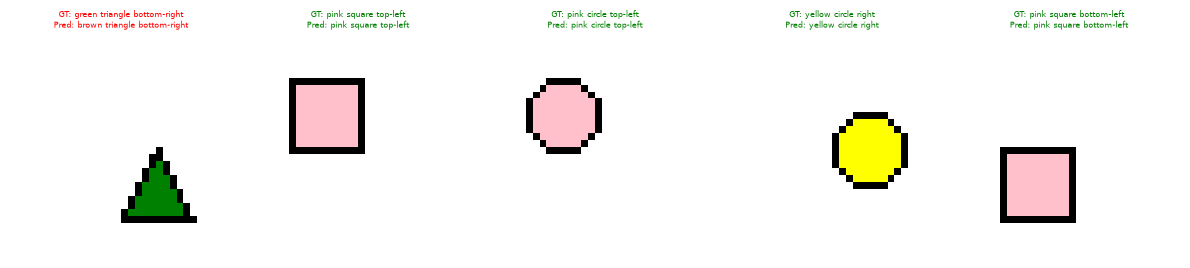

In [19]:
test_captions = [dataset.captions[i] for i in test_set.indices]
sims = results["sims"]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, idx in zip(axes, random.sample(range(len(test_set)), 5)):
    img, _ = test_set[idx]
    pred_idx = sims[idx].argmax().item()

    ax.imshow((img.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
    color = "green" if pred_idx == idx else "red"
    ax.set_title(f"GT: {test_captions[idx]}\nPred: {test_captions[pred_idx]}", fontsize=6, color=color)
    ax.axis("off")

fig.tight_layout()
plt.show()


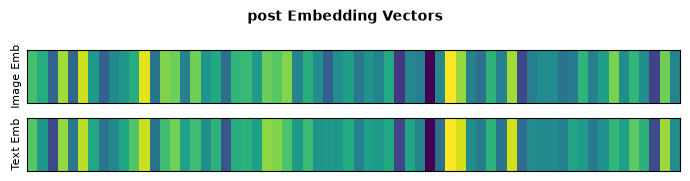

In [20]:
image_encoder.eval()
text_encoder.eval()

sample_img, sample_caption = dataset[0]
with torch.no_grad():
    img_emb = image_encoder(sample_img.unsqueeze(0).to(device))
    txt_emb = text_encoder(sample_caption.unsqueeze(0).to(device))

plot_embeddings(img_emb[0].cpu().numpy(), txt_emb[0].cpu().numpy(), "post")
